In [1]:
# making true model when given the data (forward modelling)

In [2]:
import matplotlib.pyplot as plt
# for drawing plots and figures
import numpy as np
# NumPy library : mathematical operations

import pygimli as pg
import pygimli.meshtools as mt
# used for creating mesh figures -> smaller triangles/rectangles/squares
from pygimli.physics import ert
# for various parameters 

In [3]:
pip install pygimli

Note: you may need to restart the kernel to use updated packages.


In [4]:
#Geometry def : defining to computer where ground is

world = mt.createWorld(start=[-17.5, -8], end=[17.5, 0], layers=[-1, -5, -8],
                       worldMarker=True, marker = 0)

# mt.createWorld : creates 2D soil space
# dimensions of space (refer to diagram)
# layers indicate to the computer that it has to check after every 2 m as soil profile changes
# worldMarker = True; electrical current should stay inside the space we have created 



# regions and spaces : 
# world is marker 0
# ellipse is marker 1
# polygon is marker 2


In [5]:
# heterogenous circular anamoly : target in soil so that R changes somewhere and we can track the current 
# the 2 targets here are where we think we might find materials (we get this info from other parameters)

In [6]:
# creating the red target

ellipse = mt.createCircle(pos=[-2.5, -3.0], radius=[1.5, 0.8], 
                             marker=1, area=0.1)

# breaking target into triangles
# pos is centre point, radius .. we get elliptic figure 
# marker = 1, Labelling the area.. later we can say like make marker = 1 resistance = something to diffrerentiate it 
# min area of a division of mesh should be 0.1 m^2 
# defaut mesh division shape is triangle 

In [7]:
# creating blue target 

polygon = mt.createPolygon([(1.5, -2.0), (2.5, -1.5), (4.5, -2.5), 
                               (5.5, -3.0), (4.0, -3.5), (2.8, -4.5), 
                               (1.8, -3.8)], 
                               isClosed=True, addNodes=3, 
                               interpolate='spline', marker=0)

#isClosed = True -> closed loop
# interpolate='spine', joins points with curves rather than straight lines to make it look more like a blob
# addNodes = 3 -> adds 3 nodes between each pair of points to make drawing the curve easier
# marker

In [8]:
geom = world + ellipse + polygon

# merging all geometry -> world and 2 targets 
# PieceWise Linear Complex (PLC) -> mesh logic name

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>, None)

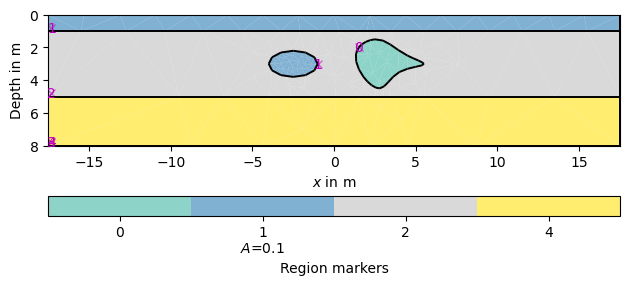

In [9]:
pg.show(geom)

In [10]:
# synthetic data generation -> we are predicting what values we should get for each parameter before testing in real world 

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>, None)

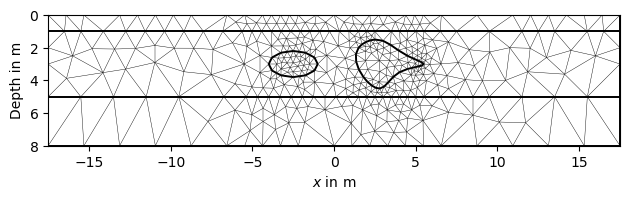

In [11]:
# making triangular meshes in geom (whole space)
mesh = mt.createMesh(geom, quality=33)

#quality=33 decides type of triangle.. or else by default long pointed needle shaped triangles are generated which are not good 

pg.show(mesh, showMesh=True)
# the above line of code shows our ellipse 

In [12]:
# OBSERVE !!! smaller triangles near edges and curves (more clustered) bc these are questionable points 

In [13]:
# Create a Dipole Dipole (‘dd’) measuring scheme where each mesh space has resistivity measuring device
# then we will get data for all meshes 
# place them in COM of all meshes 

In [14]:

# cell_centres = []
# array containing all pos coordinates 

 # for cell in mesh.cells():
   # cell_centres.append(cell.center())
# now our array contains all coms of each indiv. mesh triangle

# scheme = pg.DataContainerERT()
# for pos in cell_centres:
  #  scheme.createSensor(pos)
# setting sensor at each of these positions
# ax, _ = pg.show(mesh)
# ax gets the axis pos and _ stores te colorbar (gradient of resistivity)

# cell_centers = [mesh.cell(i).center() for i in range(mesh.cellCount())]

# Initialize a new Data Container (contains all data)
# scheme = pg.DataContainerERT()

# Create a sensor at every center point
# for pos in cell_centers:
  #  scheme.createSensor(pos)
    
# 2D model so we are extracting x and y pos of all com
# sx = [p.x() for p in scheme.sensorPositions()]
# sy = [p.y() for p in scheme.sensorPositions()]

# ax.scatter(sx, sy, color='red', s=1, label='Internal Sensors')
# s=1 mentions size of sensors 
# ax.legend()
# plt.show()






In [15]:
# sensors here refers to the diodes being used for ERT
# !! The Dipole-Dipole scheme is highly sensitive to horizontal variations and is excellent for mapping vertical structures (like dykes or cavities)
# High contact resistance is the enemy here; if the ground is too dry, geophysicists often add saltwater or bentonite mud to improve the electrical flow.

In [16]:
# the above thinking is wrong.. we can't practically put 1 sensor in every mesh.. 

# we have to put 1 sensor at periodic x co-ordinates ... so we will get the data for all vertical points at that x co-ordinate

# our horizontal length is 35m. 

11/03/26 - 10:13:06 - pyGIMLi - INFO - Cache C:\Users\anves\anaconda3\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 14): C:\Users\anves\AppData\Roaming\pygimli\Cache\5823720005807667169


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x23c925f8cd0>)

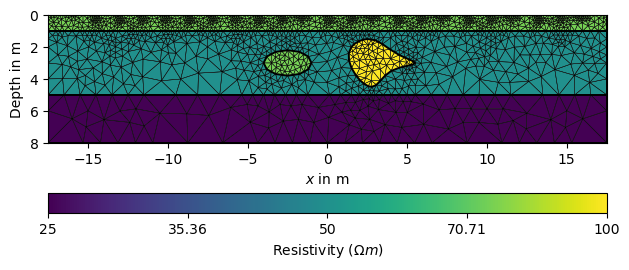

In [17]:

# Create the 35 electrode positions from -17.5 to 17.5 (35m total)
electrodes = np.linspace(start=-17.5, stop=17.5, num=25)

# Initialize the data scheme
scheme = ert.createData(elecs=electrodes, schemeName='dd')

# 21 is seen as a good option for geophysical modelling

# Put all electrode (aka sensors) positions into the PLC to enforce mesh refinement. Due to experience, its convenient to add further refinement nodes in a distance of 10% of
# electrode spacing to achieve sufficient numerical accuracy.

for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p - [0, 0.1])

# p is position vector
# the 0.1 thing is there so that we get smaller triangles in that region
# this is called mesh refinement (singularity management)

# Create a mesh for the finite element modelling with appropriate mesh quality.
mesh = mt.createMesh(geom, quality=34)

rhomap = [
    [0,100],
    [1,75],
    [2,50],
    [4, 25]
]

# Create a map to set resistivity values in the appropriate regions
# [[regionNumber, resistivity], [regionNumber, resistivity], [...]
# 1. Map the region IDs (1, 2) to the actual mesh cells
res_map = pg.solver.parseMapToCellArray(rhomap, mesh)

# 2. Plot using the mapped array
pg.show(mesh, res_map, label="Resistivity ($\Omega m$)", showMesh=True, logScale=True)

In [18]:
# Get markers from the mesh cells where we placed the sensors
# markers = [mesh.cell(i).marker() for i in range(mesh.cellCount())]

# You can now use these markers to group your data
# For example, identifying 'Anomaly' sensors vs 'Background' sensors

In [19]:
scheme.save("my_geophysical_data.dat")

1

In [20]:
# the above 1 means success
# we have saved all our quad info (custom_measurements)

11/03/26 - 10:13:07 - pyGIMLi - INFO - Data error estimate (min:max)  0.010000038556275837 : 0.010150461110483773
11/03/26 - 10:13:07 - pyGIMLi - INFO - 0.15935249909990723 803.7940945606215
11/03/26 - 10:13:07 - pyGIMLi - INFO - Simulated data Data: Sensors: 25 data: 253, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
11/03/26 - 10:13:07 - pyGIMLi - INFO - The data contains: ['a', 'b', 'err', 'i', 'ip', 'iperr', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
11/03/26 - 10:13:07 - pyGIMLi - INFO - Simulated rhoa (min/max) 35.99208099893543 71.14478854636056
11/03/26 - 10:13:07 - pyGIMLi - INFO - Selected data noise %(min/max) 1.0000038556275836 1.0150461110483773


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100


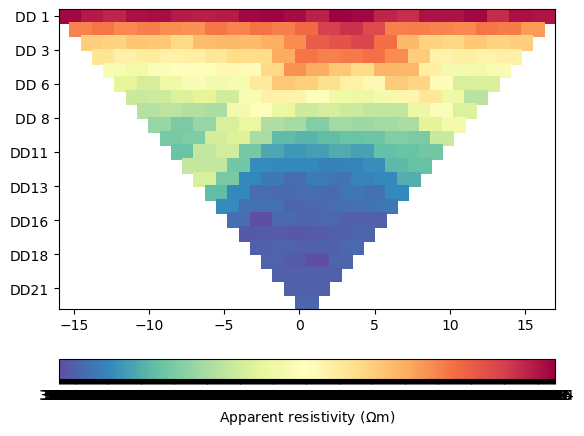

In [21]:
# Perform the modelling with the mesh and the measuring scheme itself
# return a data container with apparent resistivity values, geometric factors and estimated data errors specified by the noise setting
# The noise is also added to the data. Here 1% plus 1µV. Note, we force a specific noise seed as we want reproducable results for testing purposes.

# synthetic resistivity data

data = ert.simulate(mesh, scheme=scheme, res=rhomap, noiseLevel=1,
                    noiseAbs=0.0000001, seed=3000)

# noiseLevel=1 adds 1% level noise 
# noiseAbs=1e-6 adds small absolute value 
# !! seed = 1337 fixes random noise so result is repeatable
# all this information stored in data


pg.info(np.linalg.norm(data['err']), np.linalg.norm(data['rhoa']))
# this prints total noise magnitude and total apparent resistivity magnitude
pg.info('Simulated data', data) # prints full simulated dataset
# contains no of measurements, electrode info and resistivity measurements
pg.info('The data contains:', data.dataMap().keys())
# keys

pg.info('Simulated rhoa (min/max)', min(data['rhoa']), max(data['rhoa'])) # min and max
pg.info('Selected data noise %(min/max)', min(data['err'])*100, max(data['err'])*100) # min and max noise 

ax, cb = ert.show(data, cMap="Spectral_r", nLevs=512)

for c in ax.collections:
    c.set_edgecolor("face")
    c.set_linewidth(0.01)
    c.set_antialiased(False)

In [22]:
# reverse modelling ( ERT Inversion)

In [23]:
mgr = ert.ERTManager(data)

# ERTManager is a library which knows physics and links our data to figure

11/03/26 - 10:25:48 - pyGIMLi - INFO - Found 4 regions.
11/03/26 - 10:25:48 - pyGIMLi - INFO - Region with smallest marker set to background (marker=0)
11/03/26 - 10:25:48 - pyGIMLi - INFO - Creating forward mesh from region infos.
11/03/26 - 10:25:48 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
11/03/26 - 10:25:48 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 6692 Cells: 12884 Boundaries: 9912
11/03/26 - 10:25:48 - pyGIMLi - INFO - Use median(data values)=48.73550005744437
11/03/26 - 10:25:48 - pyGIMLi - INFO - Created startmodel from forward operator:3118, min/max=48.735500/48.735500
11/03/26 - 10:25:48 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000023C97566700>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 34.32/74.37
min/max (error): 3%/3%
min/max (start model): 48.74/48.74
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =   46.40
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    4.81 (dPhi = 89.46%) lam: 20.0
--------------------------------------------------------------------------------
chi² =    2.24 (dPhi = 53.10%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.52 (dPhi = 31.21%) lam: 20.0
--------------------------------------------------------------------------------
chi² =    0.73 (dPhi = 49.91%) lam: 20.0


#############################################################################

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x23cab151810>)

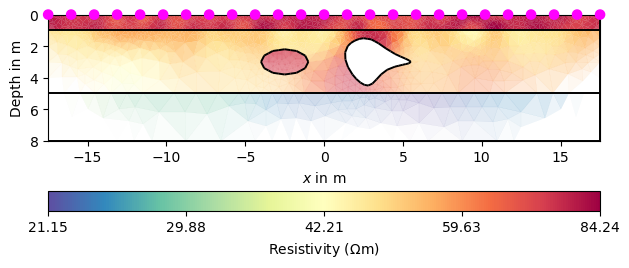

In [35]:
# 1. Generate the simulation
# We store the result in a temporary variable 'sim'
sim = mgr.simulate(mesh=mesh, res=rhomap, noiseLevel=1)

# 2. Extract ONLY the numbers from the simulation
# This ensures we are passing a vector of 171 numbers, not a container object
data['rhoa'] = sim['rhoa']

# 3. Add the error (needed for the math)
data['err'] = ert.estimateError(data, relativeError=0.03)

# 5. RUN THE INVERSION (Reverse Modeling)
# This should finally start showing 'Iteration 1...'
inv_model = mgr.invert(data=data, mesh=mesh, lam=20)

# 6. Plot the final result
mgr.showResult(inv_model, logScale=True)

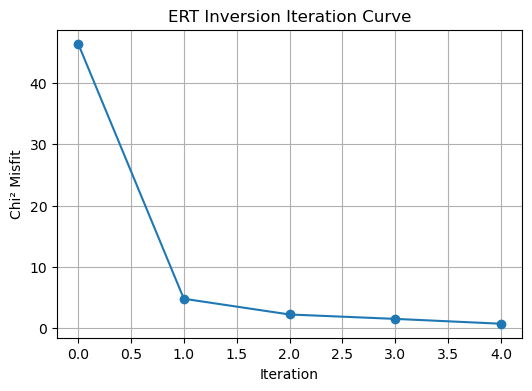

In [46]:
# generating iteration graph for the above reverse modelling
# Access inversion object
inv = mgr.inv

# Get chi-square history
chi2 = inv.chi2History
#chi2History method
# chi^2 is the measure of error/misfit

# Plot iteration graph
plt.figure(figsize=(6,4))
plt.plot(chi2, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Chi² Misfit")
plt.title("ERT Inversion Iteration Curve")
plt.grid(True)
plt.show()